Etapa uno Limpieza de dataset 


In [3]:
import pandas as pd
import numpy as np

# Cargar el dataset
print("Cargando dataset...")
df = pd.read_csv('../DataSet/household_energy_consumption.csv')

print("=" * 70)
print("ANÁLISIS INICIAL DEL DATASET")
print("=" * 70)
print(f"\nDimensiones originales: {df.shape}")
print(f"Columnas: {list(df.columns)}")

# ============================================================================
# 1. VERIFICAR DATOS FALTANTES
# ============================================================================
print("\n" + "=" * 70)
print("1. VERIFICACIÓN DE DATOS FALTANTES")
print("=" * 70)

datos_faltantes = df.isnull().sum()
print(f"\nDatos faltantes por columna:")
print(datos_faltantes)
print(f"\nTotal de filas con datos faltantes: {df.isnull().any(axis=1).sum()}")

if datos_faltantes.sum() == 0:
    print("No hay datos faltantes en el dataset")
else:
    print("Se encontraron datos faltantes")

# ============================================================================
# 2. ANÁLISIS DE MEDICIONES POR CASA
# ============================================================================
print("\n" + "=" * 70)
print("2. ANÁLISIS DE MEDICIONES POR CASA")
print("=" * 70)

mediciones_por_casa = df.groupby('Household_ID').size()
print(f"\nEstadísticas de mediciones por casa:")
print(mediciones_por_casa.describe())

print(f"\nDistribución de mediciones:")
print(mediciones_por_casa.value_counts().sort_index())

# Identificar casas con más mediciones
casas_con_mas = mediciones_por_casa[mediciones_por_casa > 7]
if len(casas_con_mas) > 0:
    print(f"\nCasas con más de 7 mediciones:")
    for casa, num_mediciones in casas_con_mas.items():
        print(f"  - {casa}: {num_mediciones} mediciones")
else:
    print(f"\nTodas las casas tienen 7 mediciones")

# ============================================================================
# 3. CONVERTIR HAS_AC A VALORES BINARIOS
# ============================================================================
print("\n" + "=" * 70)
print("3. CONVERTIR HAS_AC A VALORES BINARIOS")
print("=" * 70)

print(f"\nValores únicos antes de la conversión:")
print(df['Has_AC'].value_counts())

# Convertir Yes/No a 1/0
df['Has_AC'] = df['Has_AC'].map({'Yes': 1, 'No': 0})

print(f"\nValores únicos después de la conversión:")
print(df['Has_AC'].value_counts().sort_index())
print("Conversión completa: 'Yes' → 1, 'No' → 0")

# ============================================================================
# 4. ELIMINAR SOLO LA FILA EXTRA DE CASAS CON MÁS DE 7 MEDICIONES
# ============================================================================
print("\n" + "=" * 70)
print("4. ELIMINAR SOLO LA FILA EXTRA (MANTENER 7 MEDICIONES POR CASA)")
print("=" * 70)

print(f"\nFilas antes de eliminar: {len(df)}")

# Para cada casa con más de 7 mediciones, eliminar solo las filas extras
df_limpio = df.copy()
casas_procesadas = []

for casa in casas_con_mas.index:
    num_mediciones = mediciones_por_casa[casa]
    filas_a_eliminar = num_mediciones - 7
    
    # Obtener índices de todas las filas de esta casa
    indices_casa = df_limpio[df_limpio['Household_ID'] == casa].index
    
    # Eliminar las últimas filas extras (mantener las primeras 7)
    indices_a_eliminar = indices_casa[-filas_a_eliminar:]
    
    print(f"\nCasa {casa}:")
    print(f"  - Mediciones totales: {num_mediciones}")
    print(f"  - Filas a eliminar: {filas_a_eliminar}")
    print(f"  - Índices eliminados: {list(indices_a_eliminar)}")
    
    df_limpio = df_limpio.drop(indices_a_eliminar)
    casas_procesadas.append(casa)

filas_eliminadas = len(df) - len(df_limpio)
print(f"\n{'='*40}")
print(f"Filas después de eliminar: {len(df_limpio)}")
print(f"Total de filas eliminadas: {filas_eliminadas}")
print(f"Casas procesadas: {casas_procesadas}")

# ============================================================================
# 5. VERIFICACIÓN FINAL
# ============================================================================
print("\n" + "=" * 70)
print("5. VERIFICACIÓN FINAL DEL DATASET LIMPIO")
print("=" * 70)

print(f"\nDimensiones finales: {df_limpio.shape}")
print(f"Total de casas: {df_limpio['Household_ID'].nunique()}")

# Verificar que todas las casas tengan exactamente 7 mediciones
mediciones_final = df_limpio.groupby('Household_ID').size()
print(f"\nMediciones por casa:")
print(mediciones_final.value_counts().sort_index())

# Verificar que la casa H12857 aún existe con 7 mediciones
if 'H12857' in df_limpio['Household_ID'].values:
    num_med_h12857 = len(df_limpio[df_limpio['Household_ID'] == 'H12857'])
    print(f"\n✓ Casa H12857 mantenida con {num_med_h12857} mediciones")
    print("\nDatos de la casa H12857:")
    print(df_limpio[df_limpio['Household_ID'] == 'H12857'])

# Verificar Has_AC
print(f"\nDistribución de Has_AC:")
print(df_limpio['Has_AC'].value_counts().sort_index())
print(f"  0 (sin AC): {(df_limpio['Has_AC'] == 0).sum()} registros")
print(f"  1 (con AC): {(df_limpio['Has_AC'] == 1).sum()} registros")

# Verificar datos faltantes
print(f"\nDatos faltantes en dataset limpio: {df_limpio.isnull().sum().sum()}")

print("\n" + "=" * 70)
print("PRIMERAS 10 FILAS DEL DATASET LIMPIO")
print("=" * 70)
print(df_limpio.head(10))

# ============================================================================
# 6. GUARDAR DATASET LIMPIO
# ============================================================================
print("\n" + "=" * 70)
print("6. GUARDAR DATASET LIMPIO")
print("=" * 70)

output_path = '../Dataset/household_energy_consumption_clean.csv'
df_limpio.to_csv(output_path, index=False)
print(f"\nDataset limpio guardado exitosamente en:")
print(f"  {output_path}")

print("\n" + "=" * 70)
print("RESUMEN DE LA LIMPIEZA")
print("=" * 70)
print(f"Variable Has_AC convertida a binaria (1=Sí, 0=No)")
print(f"Verificación de datos faltantes completada")
print(f"Eliminada solo la fila extra (manteniendo las casas)")
print(f"Dataset final: {df_limpio.shape[0]} filas × {df_limpio.shape[1]} columnas")
print(f"Total de casas: {df_limpio['Household_ID'].nunique()}")
print(f"Todas las casas tienen exactamente 7 mediciones")
print("=" * 70)

Cargando dataset...
ANÁLISIS INICIAL DEL DATASET

Dimensiones originales: (90000, 7)
Columnas: ['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh']

1. VERIFICACIÓN DE DATOS FALTANTES

Datos faltantes por columna:
Household_ID              0
Date                      0
Energy_Consumption_kWh    0
Household_Size            0
Avg_Temperature_C         0
Has_AC                    0
Peak_Hours_Usage_kWh      0
dtype: int64

Total de filas con datos faltantes: 0
No hay datos faltantes en el dataset

2. ANÁLISIS DE MEDICIONES POR CASA

Estadísticas de mediciones por casa:
count    12857.000000
mean         7.000078
std          0.008819
min          7.000000
25%          7.000000
50%          7.000000
75%          7.000000
max          8.000000
dtype: float64

Distribución de mediciones:
7    12856
8        1
Name: count, dtype: int64

Casas con más de 7 mediciones:
  - H12857: 8 mediciones

3. CONVERTIR HAS_AC A VALORES 

Minimos cuadrados


In [11]:
import math

def MinimosCuadrados(X, y, decimales, metodo_ajuste='truncar'):
    """
    Regresión lineal múltiple por mínimos cuadrados
    X: matriz de variables independientes (n muestras x m variables)
    y: vector de variable dependiente
    """
    
    def truncar_decimales(numero, digitos):
        factor = 10**digitos
        return math.trunc(numero * factor) / factor
    
    def ajustar_y_formatear(valor, digitos, metodo):
        if metodo.lower() == 'truncar':
            valor_ajustado = truncar_decimales(float(valor), digitos)
        else:
            valor_ajustado = round(float(valor), digitos)
        return f"{valor_ajustado:.{digitos}f}"
    
    # Convertir a listas si son arrays de pandas
    if isinstance(X, pd.DataFrame):
        nombres_columnas = X.columns.tolist()
        X = X.values.tolist()
    else:
        nombres_columnas = [f"x{i+1}" for i in range(len(X[0]))]
    
    if isinstance(y, pd.Series):
        y = y.values.tolist()
    
    n = len(y)  # número de muestras
    m = len(X[0])  # número de variables
    
    # Agregar columna de 1s para el término independiente
    X_aumentada = [[1.0] + fila for fila in X]
    
    # Construir X^T * X (matriz de coeficientes normales)
    XTX = [[0.0] * (m + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        for j in range(m + 1):
            for k in range(n):
                XTX[i][j] += X_aumentada[k][i] * X_aumentada[k][j]
    
    # Construir X^T * y (vector del lado derecho)
    XTy = [0.0] * (m + 1)
    for i in range(m + 1):
        for k in range(n):
            XTy[i] += X_aumentada[k][i] * y[k]
    
    # Matriz aumentada [XTX | XTy]
    matriz_aumentada = []
    for i in range(m + 1):
        fila = XTX[i] + [XTy[i]]
        matriz_aumentada.append(fila)
    
    # Gauss-Jordan
    for i in range(m + 1):
        # Pivoteo
        fila_max = i
        for k in range(i + 1, m + 1):
            if abs(matriz_aumentada[k][i]) > abs(matriz_aumentada[fila_max][i]):
                fila_max = k
        matriz_aumentada[i], matriz_aumentada[fila_max] = \
            matriz_aumentada[fila_max], matriz_aumentada[i]
        
        # Normalizar fila pivote
        divisor = matriz_aumentada[i][i]
        if abs(divisor) < 1e-10:
            continue
        for j in range(i, m + 2):
            matriz_aumentada[i][j] /= divisor
        
        # Hacer ceros en otras filas
        for k in range(m + 1):
            if k != i:
                factor = matriz_aumentada[k][i]
                for j in range(i, m + 2):
                    matriz_aumentada[k][j] -= factor * matriz_aumentada[i][j]
    
    # Extraer coeficientes
    coeficientes_raw = [matriz_aumentada[i][m + 1] for i in range(m + 1)]
    
    # Ajustar y formatear
    intercepto = ajustar_y_formatear(coeficientes_raw[0], decimales, metodo_ajuste)
    coeficientes = [ajustar_y_formatear(c, decimales, metodo_ajuste) 
                    for c in coeficientes_raw[1:]]
    
    return intercepto, coeficientes, nombres_columnas


# Dataset limpio
df = pd.read_csv('../Dataset/household_energy_consumption_clean.csv')

ecuaciones = {}

# Ajustar un modelo por cada día (1 a 7)
for dia in range(1, 8):
    df_dia = df[pd.to_datetime(df['Date']).dt.day == dia]
    if df_dia.empty:
        continue
    
    X = df_dia.drop(columns=['Household_ID', 'Date', 'Energy_Consumption_kWh'])
    y = df_dia['Energy_Consumption_kWh']
    
    # Usar tu función personalizada
    intercepto, coeficientes, nombres = MinimosCuadrados(
        X, y, decimales=4, metodo_ajuste='truncar'
    )
    
    ecuaciones[dia] = {
        'intercepto': intercepto,
        'coeficientes': dict(zip(nombres, coeficientes))
    }

# Mostrar las ecuaciones
for dia, eq in ecuaciones.items():
    print(f"\nDía {dia}:")
    terminos = [f"{coef}*{var}" for var, coef in eq['coeficientes'].items()]
    print(f"  y = {eq['intercepto']} + " + " + ".join(terminos))


Día 1:
  y = -0.0472 + 0.9472*Household_Size + 0.0245*Avg_Temperature_C + -0.4845*Has_AC + 1.6518*Peak_Hours_Usage_kWh

Día 2:
  y = 0.0350 + 0.9428*Household_Size + 0.0191*Avg_Temperature_C + -0.4692*Has_AC + 1.6535*Peak_Hours_Usage_kWh

Día 3:
  y = 0.0370 + 0.9487*Household_Size + 0.0194*Avg_Temperature_C + -0.4734*Has_AC + 1.6480*Peak_Hours_Usage_kWh

Día 4:
  y = 0.0484 + 0.9483*Household_Size + 0.0189*Avg_Temperature_C + -0.4676*Has_AC + 1.6473*Peak_Hours_Usage_kWh

Día 5:
  y = 0.0306 + 0.9514*Household_Size + 0.0195*Avg_Temperature_C + -0.4496*Has_AC + 1.6454*Peak_Hours_Usage_kWh

Día 6:
  y = 0.0276 + 0.9501*Household_Size + 0.0202*Avg_Temperature_C + -0.4955*Has_AC + 1.6447*Peak_Hours_Usage_kWh

Día 7:
  y = 0.0671 + 0.9573*Household_Size + 0.0176*Avg_Temperature_C + -0.4472*Has_AC + 1.6391*Peak_Hours_Usage_kWh


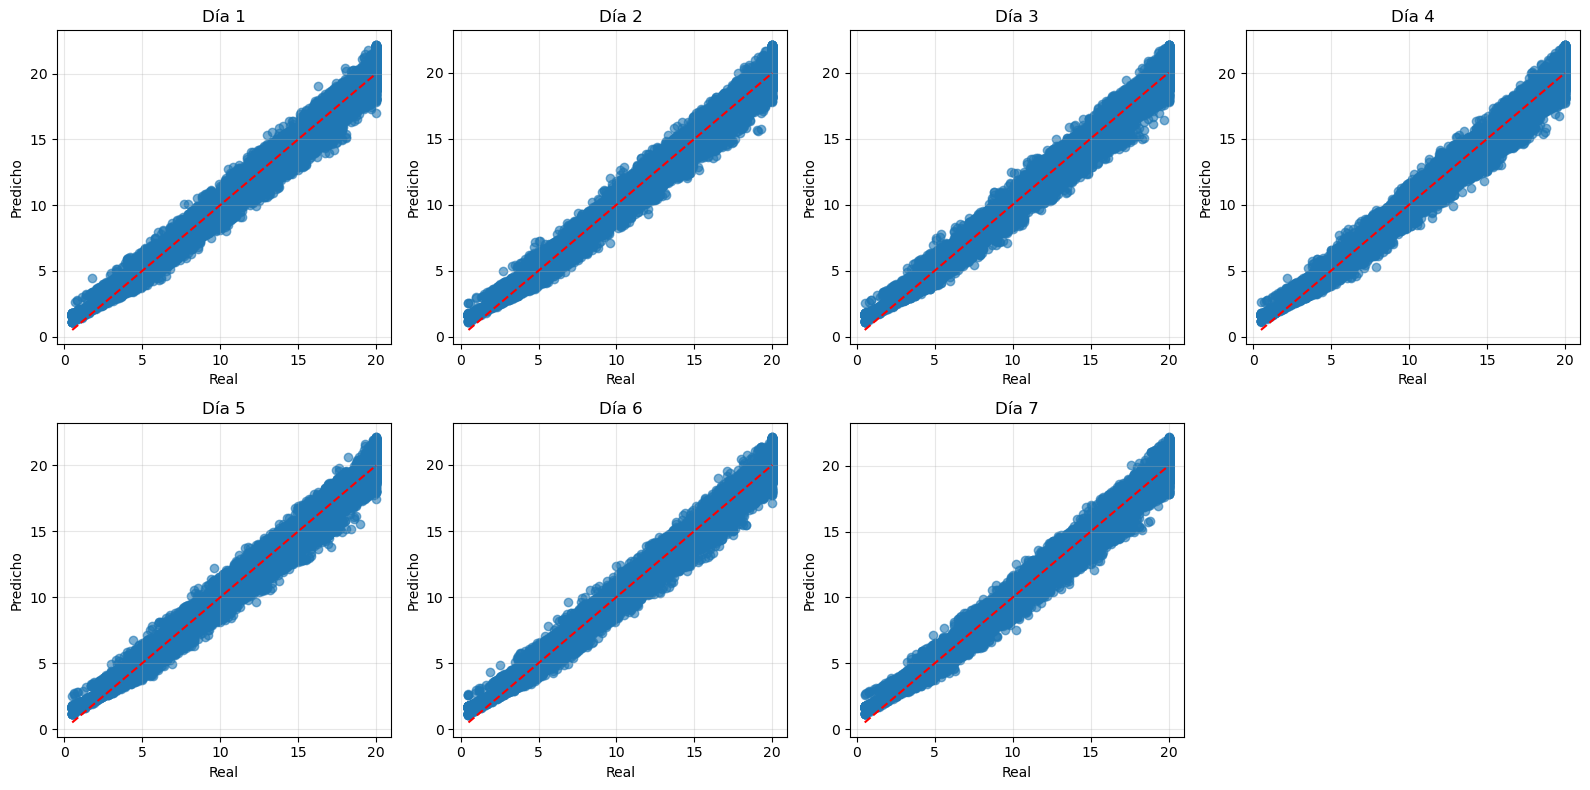

In [13]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, dia in enumerate(range(1, 8)):
    df_dia = df[pd.to_datetime(df['Date']).dt.day == dia]
    if df_dia.empty:
        continue
    
    X = df_dia.drop(columns=['Household_ID', 'Date', 'Energy_Consumption_kWh'])
    y = df_dia['Energy_Consumption_kWh']
    
    intercepto, coeficientes, nombres = MinimosCuadrados(
        X, y, decimales=4, metodo_ajuste='truncar'
    )
    
    # Predicciones
    X_lista = X.values.tolist()
    y_pred = []
    for fila in X_lista:
        pred = float(intercepto)
        for i, nombre in enumerate(nombres):
            pred += float(coeficientes[i]) * fila[i]
        y_pred.append(pred)
    
    # Graficar
    axes[idx].scatter(y.tolist(), y_pred, alpha=0.6)
    axes[idx].plot([min(y), max(y)], [min(y), max(y)], 'r--')
    axes[idx].set_title(f'Día {dia}')
    axes[idx].set_xlabel('Real')
    axes[idx].set_ylabel('Predicho')
    axes[idx].grid(True, alpha=0.3)

# Ocultar subplot extra
axes[7].axis('off')

plt.tight_layout()
plt.show()


Día 1:
  y = -0.0472 + 0.9472*Household_Size + 0.0245*Avg_Temperature_C + -0.4845*Has_AC + 1.6518*Peak_Hours_Usage_kWh + 0.0000*Dia

Día 2:
  y = 0.0350 + 0.9428*Household_Size + 0.0191*Avg_Temperature_C + -0.4692*Has_AC + 1.6535*Peak_Hours_Usage_kWh + 0.0000*Dia

Día 3:
  y = 0.0370 + 0.9487*Household_Size + 0.0194*Avg_Temperature_C + -0.4734*Has_AC + 1.6480*Peak_Hours_Usage_kWh + 0.0000*Dia

Día 4:
  y = 0.0484 + 0.9483*Household_Size + 0.0189*Avg_Temperature_C + -0.4676*Has_AC + 1.6473*Peak_Hours_Usage_kWh + 0.0000*Dia

Día 5:
  y = 0.0306 + 0.9514*Household_Size + 0.0195*Avg_Temperature_C + -0.4496*Has_AC + 1.6454*Peak_Hours_Usage_kWh + 0.0000*Dia

Día 6:
  y = 0.0276 + 0.9501*Household_Size + 0.0202*Avg_Temperature_C + -0.4955*Has_AC + 1.6447*Peak_Hours_Usage_kWh + 0.0000*Dia

Día 7:
  y = 0.0671 + 0.9573*Household_Size + 0.0176*Avg_Temperature_C + -0.4472*Has_AC + 1.6391*Peak_Hours_Usage_kWh + 0.0000*Dia


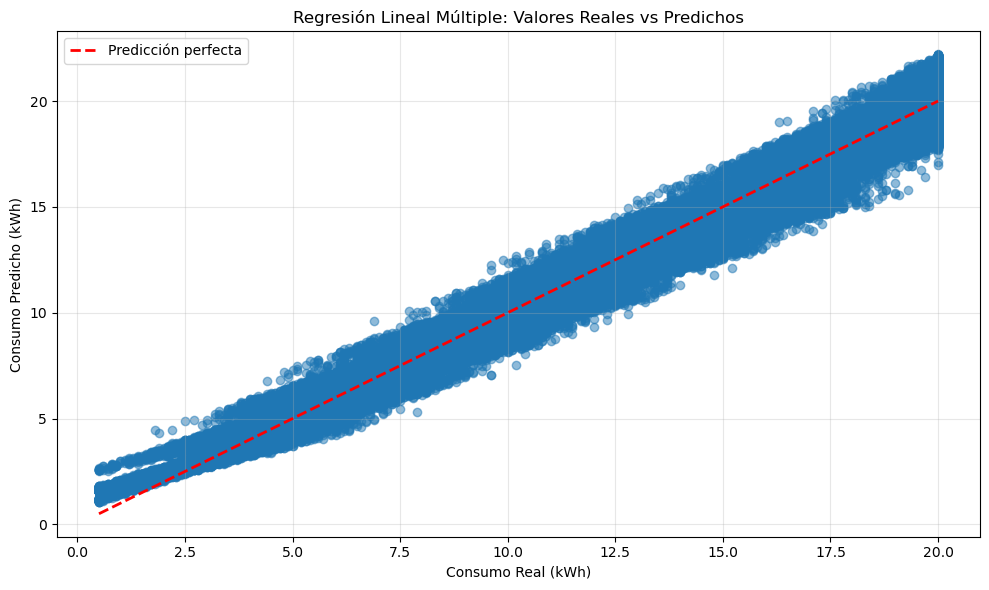

In [19]:


ecuaciones = {}
predicciones_totales = []
reales_totales = []

# Ajustar un modelo por cada día (1 a 7)
for dia in range(1, 8):
    df_dia = df[pd.to_datetime(df['Date']).dt.day == dia]
    if df_dia.empty:
        continue
    
    X = df_dia.drop(columns=['Household_ID', 'Date', 'Energy_Consumption_kWh'])
    y = df_dia['Energy_Consumption_kWh']
    
    # Usar tu función personalizada
    intercepto, coeficientes, nombres = MinimosCuadrados(
        X, y, decimales=4, metodo_ajuste='truncar'
    )
    
    ecuaciones[dia] = {
        'intercepto': intercepto,
        'coeficientes': dict(zip(nombres, coeficientes))
    }
    
    # Calcular predicciones
    X_lista = X.values.tolist()
    y_pred = []
    for fila in X_lista:
        pred = float(intercepto)
        for i, nombre in enumerate(nombres):
            pred += float(coeficientes[i]) * fila[i]
        y_pred.append(pred)
    
    predicciones_totales.extend(y_pred)
    reales_totales.extend(y.tolist())

# Mostrar las ecuaciones
for dia, eq in ecuaciones.items():
    print(f"\nDía {dia}:")
    terminos = [f"{coef}*{var}" for var, coef in eq['coeficientes'].items()]
    print(f"  y = {eq['intercepto']} + " + " + ".join(terminos))

# GRÁFICA: Valores Reales vs Predichos
plt.figure(figsize=(10, 6))
plt.scatter(reales_totales, predicciones_totales, alpha=0.5)
plt.plot([min(reales_totales), max(reales_totales)], 
         [min(reales_totales), max(reales_totales)], 
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Consumo Real (kWh)')
plt.ylabel('Consumo Predicho (kWh)')
plt.title('Regresión Lineal Múltiple: Valores Reales vs Predichos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()